In [34]:
# Import neccessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# go to project root
PROJECT_ROOT = Path().resolve().parents[1]

sys.path.append(str(PROJECT_ROOT))

import src.utils.paths as paths
import importlib
importlib.reload(paths)
from numpy.linalg import inv
import plotly.graph_objects as go


from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
import pandas as pd

In [17]:
# Load the data
data = pd.read_csv(paths.MERGED_DATA_DIR / "all_variables.csv")

# Remove the 'Date' column
data = data.drop(columns=['date'])

In [18]:
# Reset index (remove Date index)
data = data.reset_index(drop=True)

# Set index from 1 to N
data.index = range(1, len(data) + 1)

# Rename columns
data = data.rename(columns={"output": "output_growth"})

# Check
print(data.head())

   cash_rate  inflation  output_growth  unemployment     wages
1   5.325397        0.7            0.3      6.536283  0.560224
2   5.899616        0.6            1.1      6.247424  0.974930
3   6.163043        0.5            0.1      6.040110  0.827586
4   6.250000        0.6           -0.3      6.138903  0.957592
5   5.881818        1.0            0.9      6.401236  0.948509


<h2>Visualisation for all variables</h2>

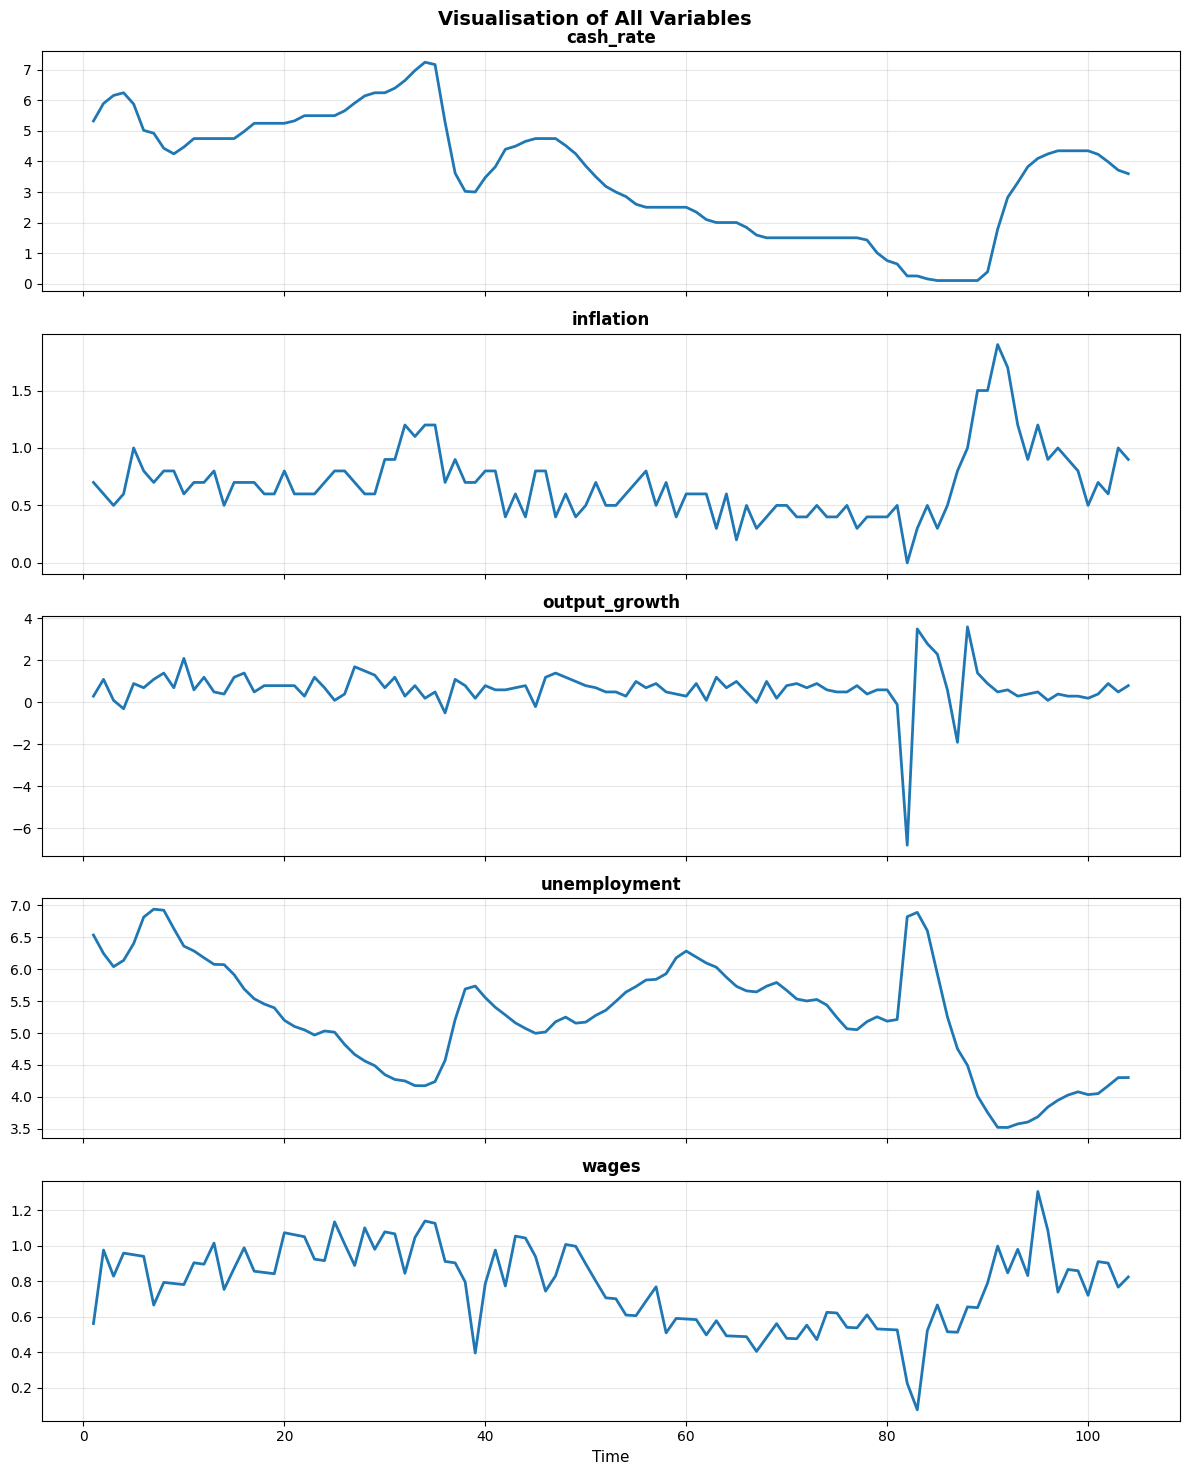

In [ ]:
n = len(data.columns)

fig, axes = plt.subplots(n, 1, figsize=(12, 3*n), sharex=True)

# handle single variable case
if n == 1:
    axes = [axes]

for i, column in enumerate(data.columns):
    axes[i].plot(data.index, data[column], linewidth=2)
    axes[i].set_title(column, fontsize=12, weight='bold')
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel("Time", fontsize=11)

plt.suptitle("Visualisation of All Variables", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

<h2>Construct BVAR architechture</h2>

In [8]:
# build VAR lag matrix

def make_var_lagged_data(data, p):
    """
    data: (T, n) with T is the length of the data, n is the number of variables
    Returns:
        Y: (T-p, n)
        X: (T-p, 1 + n*p)   [constant + lagged values]
    """
    if isinstance(data, pd.DataFrame):
        values = data.values
        colnames = list(data.columns)
    else:
        values = np.asarray(data)
        colnames = [f"y{i}" for i in range(values.shape[1])]

    T, n = values.shape
    Y = values[p:]
    X_parts = [np.ones((T - p, 1))]  # intercept

    for lag in range(1, p + 1):
        X_parts.append(values[p - lag:T - lag])

    X = np.hstack(X_parts)
    return Y, X, colnames

# Estimate residual variances from univariate AR(p) models for each variable
def estimate_ar_residual_variances(data, p):
    """
    Returns sigma_i^2 (variance of the noise) for each variable from univariate AR(p).
    """
    values = data.values if isinstance(data, pd.DataFrame) else np.asarray(data)
    T, n = values.shape
    sigmas2 = np.zeros(n)

    for i in range(n):
        y = values[:, i]
        Y = y[p:]
        X_parts = [np.ones((T - p, 1))]
        for lag in range(1, p + 1):
            X_parts.append(y[p - lag:T - lag].reshape(-1, 1))
        X = np.hstack(X_parts)

        beta_ols = inv(X.T @ X) @ (X.T @ Y)
        resid = Y - X @ beta_ols
        sigmas2[i] = np.var(resid, ddof=X.shape[1])

    return sigmas2


# Build Minnesota prior for one equation
# lam1: overall tightness, lam2: cross-variable tightness, lam3: intercept tightness, prior_mean_own_lag1: prior mean for own first lag (default 0, can be set to 1 for level variables)
def minnesota_prior_one_equation(n, p, eq_i, sigmas2, lam1=0.2, lam2=0.5, lam3=100.0,
                                 prior_mean_own_lag1=0.0):
    """
    Prior for one equation:
      beta_i ~ N(b0_i, V0_i) where V0_i is diagonal with elements of the prior covariance matrix for equation i.
    """
    k = 1 + n * p
    b0 = np.zeros(k)
    V0 = np.zeros((k, k))

    # Prior mean: own first lag can be 1 for level variables, 0 for growth variables
    own_lag1_index = 1 + eq_i
    b0[own_lag1_index] = prior_mean_own_lag1

    # Intercept variance
    V0[0, 0] = lam3**2

    # Lag coefficient variances
    for lag in range(1, p + 1):
        for j in range(n):
            idx = 1 + (lag - 1) * n + j

            if j == eq_i:
                # own lag
                var = (lam1 / (lag**1))**2
            else:
                # cross lag
                var = ((lam1 * lam2) / (lag**1))**2 * (sigmas2[eq_i] / sigmas2[j])

            V0[idx, idx] = var

    return b0, V0

<h2>Fit the data into the model </h2>

In [ ]:
# Fit BVAR equation-by-equation
def fit_bvar_minnesota(data, p=4, lam1=0.2, lam2=0.5, lam3=100.0,
                       prior_means=None):
    """
    Fits BVAR with Minnesota prior equation-by-equation.
    """
    Y, X, colnames = make_var_lagged_data(data, p)
    T_eff, n = Y.shape
    k = X.shape[1]

    sigmas2 = estimate_ar_residual_variances(data, p)

    if prior_means is None:
        prior_means = np.zeros(n)

    B_post = np.zeros((k, n))   # posterior mean coefficients
    V_post_list = []

    for i in range(n):
        y_i = Y[:, i]

        b0, V0 = minnesota_prior_one_equation(
            n=n,
            p=p,
            eq_i=i,
            sigmas2=sigmas2,
            lam1=lam1,
            lam2=lam2,
            lam3=lam3,
            prior_mean_own_lag1=prior_means[i]
        )

        V0_inv = inv(V0)
        V_post = inv(V0_inv + X.T @ X / sigmas2[i])
        b_post = V_post @ (V0_inv @ b0 + (X.T @ y_i) / sigmas2[i])

        B_post[:, i] = b_post
        V_post_list.append(V_post)

    model = {
        "B_post": B_post,
        "V_post_list": V_post_list,
        "p": p,
        "n": n,
        "k": k,
        "columns": colnames,
        "sigmas2": sigmas2
    }
    return model

In [ ]:
#  Forecast h steps ahead
def forecast_bvar(model, data, h=4):
    """
    Recursive multi-step forecast.
    data: original training data as DataFrame
    h: forecast horizon
    """
    values = data.values.copy()
    B = model["B_post"]
    p = model["p"]
    n = model["n"]
    cols = model["columns"]

    history = values.copy()
    forecasts = []

    for _ in range(h):
        x = [1.0]  # intercept
        for lag in range(1, p + 1):
            x.extend(history[-lag, :])
        x = np.array(x)

        y_hat = x @ B
        forecasts.append(y_hat)
        history = np.vstack([history, y_hat])

    forecast_df = pd.DataFrame(forecasts, columns=cols)
    return forecast_df


<h2> Rolling and hold-out example </h2>


In [25]:

# Split the last 2 years (8 observations) as a test
h = 8
train = data.iloc[:-h].copy()
test = data.iloc[-h:].copy()

# simple priro: mean is all 0, can change this later according to their suggestion
prior_means = [0, 0, 0, 0, 0]

model = fit_bvar_minnesota(
    train,
    p=4,
    lam1=0.2,      
    lam2=0.5,      
    lam3=100.0,   
    prior_means=prior_means
)

forecast = forecast_bvar(model, train, h=h)

print("Forecasts:")
print(forecast)

print("\nActual test data:")
print(test.reset_index(drop=True))



Forecasts:
   cash_rate  inflation  output_growth  unemployment     wages
0   4.341546   0.942433       0.400540      3.982011  0.957496
1   4.382947   0.925089       0.483602      4.136634  0.952575
2   4.405911   0.901524       0.522274      4.278341  0.945534
3   4.408790   0.882647       0.522169      4.404829  0.928836
4   4.396252   0.862424       0.542782      4.520282  0.916379
5   4.373661   0.843935       0.568113      4.623636  0.906149
6   4.343878   0.826632       0.588688      4.714880  0.896251
7   4.308772   0.810774       0.605066      4.794768  0.886731

Actual test data:
   cash_rate  inflation  output_growth  unemployment     wages
0   4.350000        1.0            0.4      3.945441  0.737760
1   4.350000        0.9            0.3      4.026495  0.865513
2   4.350000        0.8            0.3      4.077705  0.858086
3   4.350000        0.5            0.2      4.033979  0.719895
4   4.233333        0.7            0.4      4.049860  0.909682
5   3.986667        0.6  

<h2> Evaluation on the model </h2>

In [ ]:
# Evaluiatiopn based on RMSE and MAE for each variable
forecast.index = test.index

rmse = np.sqrt(((forecast.values - test.values) ** 2).mean(axis=0))
mae = np.abs(forecast.values - test.values).mean(axis=0)

eval_df = pd.DataFrame({
    "Variable": data.columns,
    "RMSE": rmse,
    "MAE": mae
})

print("\nEvaluation:")
print(eval_df)


Evaluation:
        Variable      RMSE       MAE
0      cash_rate  0.367389  0.255250
1      inflation  0.188604  0.154472
2  output_growth  0.213105  0.185860
3   unemployment  0.359074  0.318480
4          wages  0.126627  0.101054


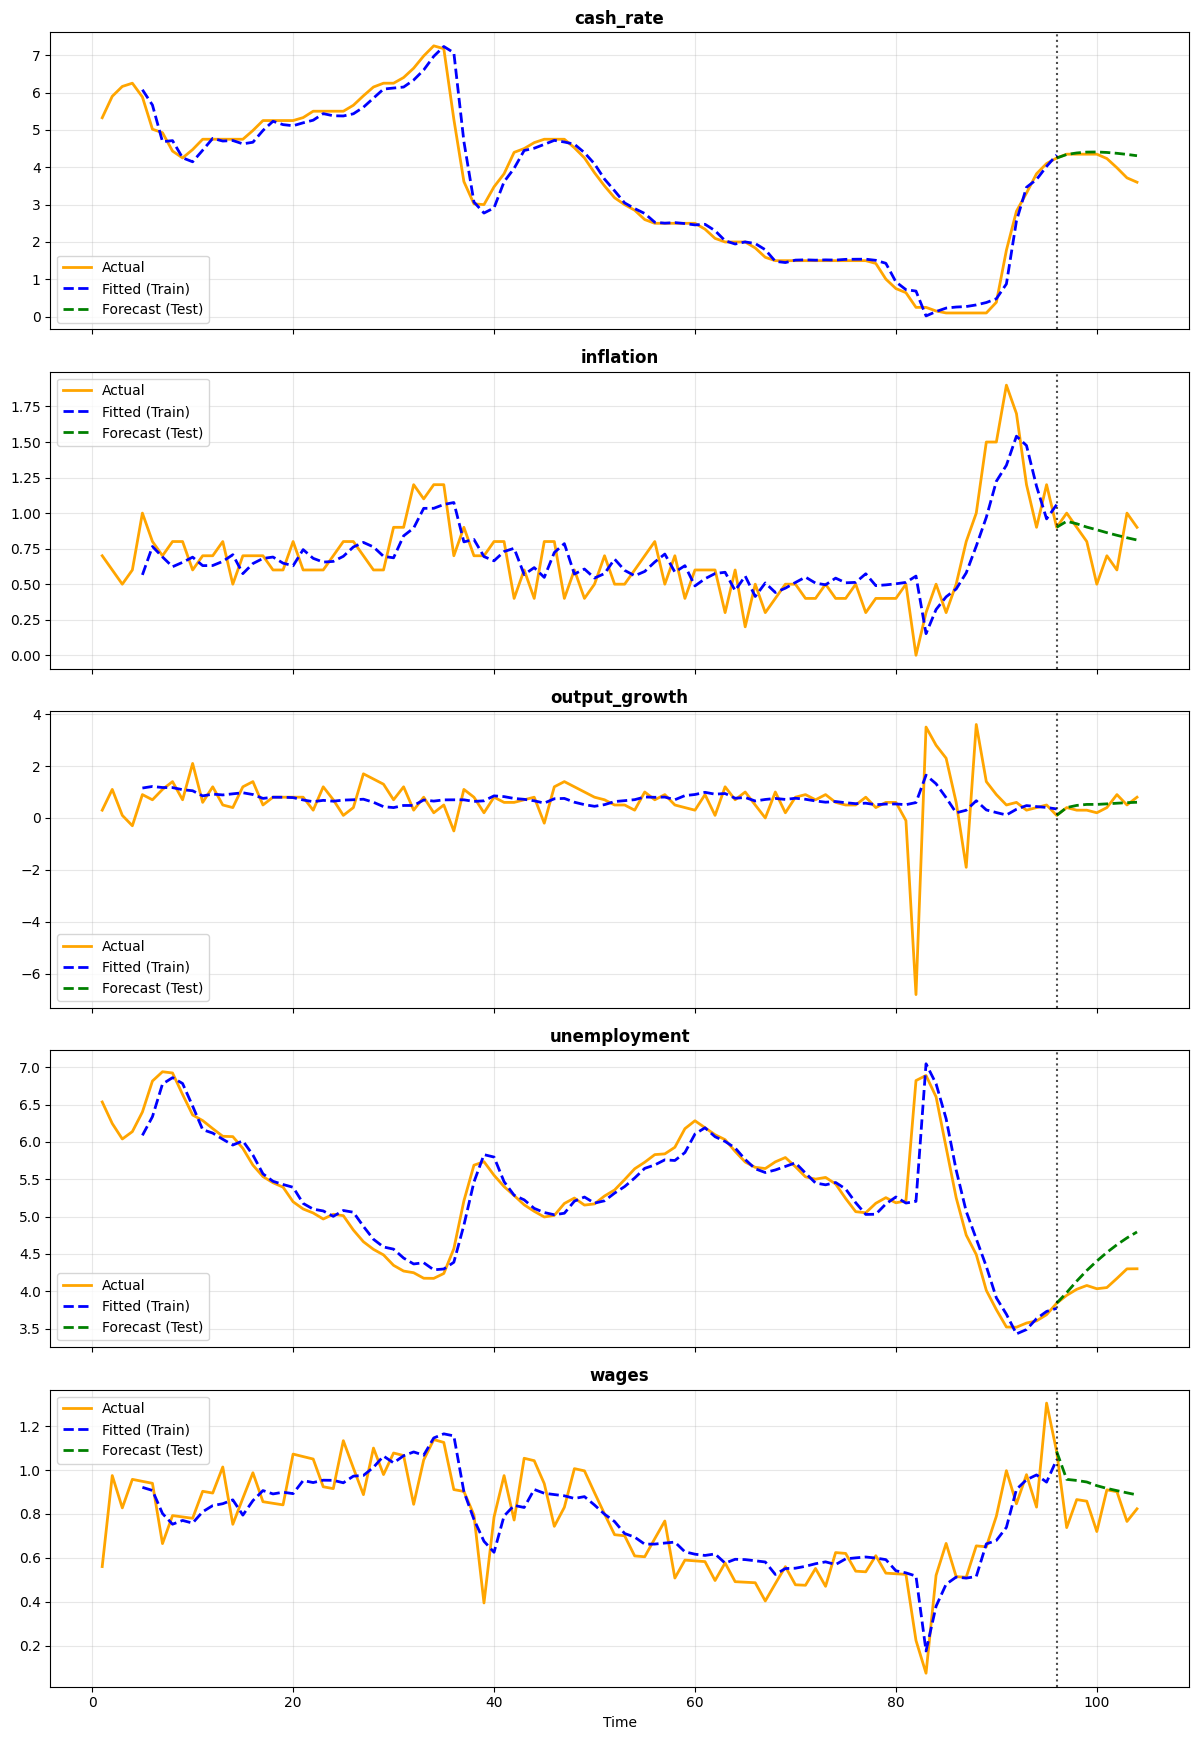

In [33]:
# in-sample fitted values for training data
Y_train, X_train, _ = make_var_lagged_data(train, p=model["p"])
fitted_train = pd.DataFrame(
    X_train @ model["B_post"],
    columns=train.columns,
    index=train.index[model["p"]:]
)

import matplotlib.pyplot as plt
import pandas as pd

# make forecast use test index
forecast.index = test.index

# last point of fitted period / split
split_point = train.index[-1]

n = len(data.columns)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.5 * n), sharex=True)

if n == 1:
    axes = [axes]

for i, col in enumerate(data.columns):
    # actual full series
    axes[i].plot(data.index, data[col], label="Actual", linewidth=2, color="orange")

    # fitted values during training
    axes[i].plot(
        fitted_train.index,
        fitted_train[col],
        label="Fitted (Train)",
        linewidth=2,
        linestyle="--",
        color="blue"
    )

    # forecast connected to last training point
    forecast_x = pd.Index([train.index[-1]]).append(forecast.index)
    forecast_y = pd.concat([train[col].iloc[[-1]], forecast[col]])
    axes[i].plot(
        forecast_x,
        forecast_y,
        label="Forecast (Test)",
        linewidth=2,
        linestyle="--",
        color="green"
    )

    # split line
    axes[i].axvline(split_point, linestyle=":", linewidth=1.5, color="black", alpha=0.7)

    axes[i].set_title(col, fontsize=12, weight="bold")
    axes[i].grid(alpha=0.3)
    axes[i].legend()

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

<h2> interactive plot </h2>

In [36]:
# safer renderer
pio.renderers.default = "browser"

# in-sample fitted values for training data
Y_train, X_train, _ = make_var_lagged_data(train, p=model["p"])
fitted_train = pd.DataFrame(
    X_train @ model["B_post"],
    columns=train.columns,
    index=train.index[model["p"]:]
)

# make forecast use test index
forecast.index = test.index

split_point = train.index[-1]
n = len(data.columns)

fig = make_subplots(
    rows=n,
    cols=1,
    shared_xaxes=True,
    subplot_titles=list(data.columns),
    vertical_spacing=0.04
)

for i, col in enumerate(data.columns, start=1):
    # Actual full series
    fig.add_trace(
        go.Scatter(
            x=data.index,
            y=data[col],
            mode="lines",
            name=f"{col} - Actual",
            line=dict(width=2, color="orange"),
            hovertemplate="Index=%{x}<br>Actual=%{y:.4f}<extra></extra>"
        ),
        row=i, col=1
    )

    # Fitted values on training set
    fig.add_trace(
        go.Scatter(
            x=fitted_train.index,
            y=fitted_train[col],
            mode="lines",
            name=f"{col} - Fitted (Train)",
            line=dict(width=2, dash="dash", color="blue"),
            hovertemplate="Index=%{x}<br>Fitted=%{y:.4f}<extra></extra>"
        ),
        row=i, col=1
    )

    # Forecast on test set, connected to last training point
    forecast_x = pd.Index([train.index[-1]]).append(forecast.index)
    forecast_y = pd.concat([train[col].iloc[[-1]], forecast[col]])

    fig.add_trace(
        go.Scatter(
            x=forecast_x,
            y=forecast_y,
            mode="lines",
            name=f"{col} - Forecast (Test)",
            line=dict(width=2, dash="dash", color="green"),
            hovertemplate="Index=%{x}<br>Forecast=%{y:.4f}<extra></extra>"
        ),
        row=i, col=1
    )

    # vertical split line
    fig.add_vline(
        x=split_point,
        line_width=1.5,
        line_dash="dot",
        line_color="black",
        row=i, col=1
    )

fig.update_layout(
    height=300 * n,
    title="BVAR: Actual vs Fitted vs Forecast",
    template="plotly_white",
    hovermode="x unified"
)

fig.update_xaxes(title_text="Time", row=n, col=1)

fig.show()